<a href="https://colab.research.google.com/github/Ciano-Domenico/Progetto_EVWSD_ML/blob/Domenico/progetto_EVWSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
# Mount Drive e setup cartelle
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Progetto_EVWSD_ML"
IMAGES_DIR = os.path.join(DRIVE_PROJECT_PATH, "data/images")
HF_CACHE_DIR = os.path.join(DRIVE_PROJECT_PATH, "data/hf_cache")
IMAGES_ROOT  = os.path.join(IMAGES_DIR, "imgs")

os.makedirs(HF_CACHE_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [118]:
!pip install -q sentence-transformers datasets pillow torch

In [119]:
from datasets import load_dataset
from huggingface_hub import hf_hub_download
import zipfile

dataset = load_dataset("swap-uniba/EVWSD-ITA", cache_dir=HF_CACHE_DIR)

# scarica immagini solo se non già presenti
if not os.path.exists(IMAGES_ROOT):
    zip_path = hf_hub_download(
        repo_id="swap-uniba/EVWSD-ITA",
        filename="imgs.zip",
        repo_type="dataset",
        cache_dir=HF_CACHE_DIR
    )
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(IMAGES_DIR)
    print("Immagini estratte.")
else:
    print("Immagini già presenti.")

Immagini già presenti.


In [121]:
import torch
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# vision encoder: CLIP base (stesso backbone del modello multilingue)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("Modello CLIP caricato.")

Device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Modello CLIP caricato.


In [122]:
from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer("sentence-transformers/clip-ViT-B-32-multilingual-v1", device=device)
text_model.eval()
print("Modello SentenceTransformer caricato.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Modello SentenceTransformer caricato.


In [123]:
import random
from PIL import Image

IMG_EXT = ".png"
N_CANDIDATE = 10

def load_image(img_path_str):
    full_path = os.path.join(IMAGES_ROOT, img_path_str + IMG_EXT)
    if not os.path.exists(full_path):
        return None
    return Image.open(full_path).convert("RGB")

def encode_images(pil_images, model, processor, device):
    inputs = processor(images=pil_images, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        vision_out = model.vision_model(pixel_values=inputs["pixel_values"])
        emb = model.visual_projection(vision_out.pooler_output)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu()

def scegli_pacchetto_casuale(dataset, n=N_CANDIDATE):
    idx = random.randint(0, len(dataset["train"]) - 1)
    row = dataset["train"][idx]

    # 1. prendi co-iponimi (più simili)
    # 2. poi stesso lemma senso diverso
    # 3. se non bastano, riempi con immagini casuali da altre istanze
    candidati = {}  # path → img, mantiene unicità

    for path, is_co in zip(row["images"], row["is_co_hyp"]):
        if path not in candidati:
            img = load_image(path)
            if img is not None:
                candidati[path] = (img, "co_hyp" if is_co else "same_lemma")

    # se non bastano riempi con immagini casuali da altre istanze
    tentativi = 0
    while len(candidati) < n and tentativi < 1000:
        tentativi += 1
        row_rand = dataset["train"][random.randint(0, len(dataset["train"]) - 1)]
        for path in row_rand["images"]:
            if path not in candidati and len(candidati) < n:
                img = load_image(path)
                if img is not None:
                    candidati[path] = (img, "random")

    # se ci sono più di n, priorità: co_hyp > same_lemma > random
    if len(candidati) > n:
        co_hyp_paths   = [p for p, (_, t) in candidati.items() if t == "co_hyp"]
        same_lem_paths = [p for p, (_, t) in candidati.items() if t == "same_lemma"]

        paths = co_hyp_paths + same_lem_paths
        if len(paths) < n:
            random_paths = [p for p, (_, t) in candidati.items() if t == "random"]
            paths += random.sample(random_paths, n - len(paths))
        elif len(paths) > n:
            paths = paths[:n]
    else:
        paths = list(candidati.keys())

    random.shuffle(paths)
    immagini = [candidati[p][0] for p in paths]
    tipi     = [candidati[p][1] for p in paths]

    embeddings_candidati = encode_images(immagini, clip_model, clip_processor, device)

    metadati = {
        "id":           row["id"],
        "lemma":        row["lemma"],
        "gloss":        row["gloss"],
        "n_co_hyp":     tipi.count("co_hyp"),
        "n_same_lemma": tipi.count("same_lemma"),
        "n_random":     tipi.count("random"),
        "n_candidate":  len(immagini),
    }

    return immagini, embeddings_candidati, metadati

Istanza:         bn:00078306n
Lemma:           dollaro
Gloss:           Il dollaro è la valuta ufficiale Trinidad e Tobago.
Co-iponimi:      4
Stesso lemma:    2
Casuali:         4
Totale:          10
Shape embeddings: torch.Size([10, 512])


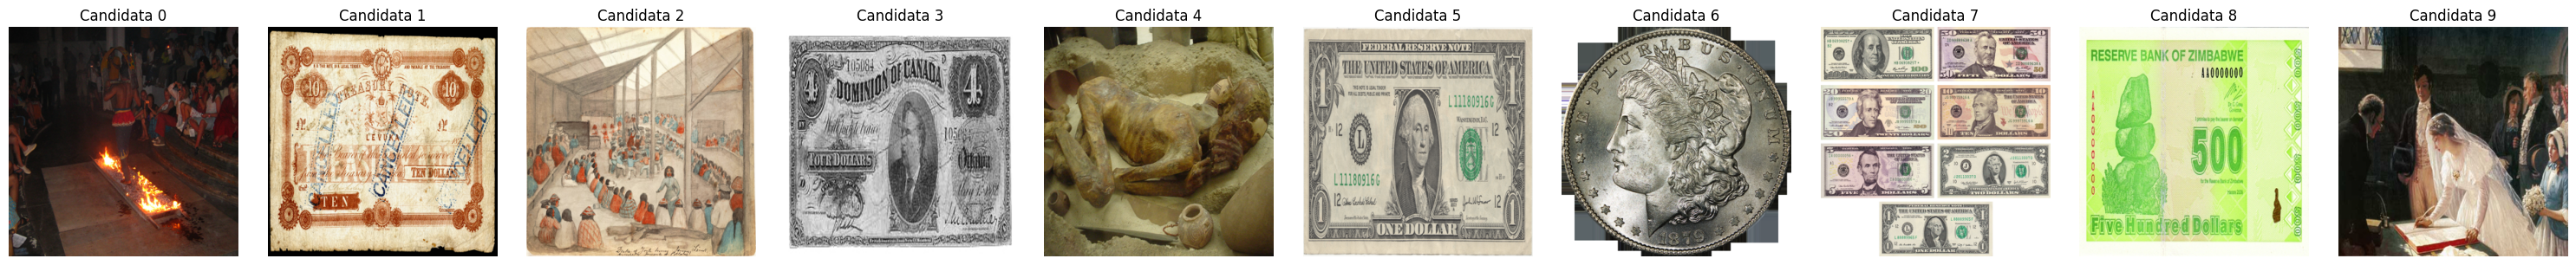

In [124]:
import matplotlib.pyplot as plt

immagini, embeddings_candidati, metadati = scegli_pacchetto_casuale(dataset)

print(f"Istanza:         {metadati['id']}")
print(f"Lemma:           {metadati['lemma']}")
print(f"Gloss:           {metadati['gloss']}")
print(f"Co-iponimi:      {metadati['n_co_hyp']}")
print(f"Stesso lemma:    {metadati['n_same_lemma']}")
print(f"Casuali:         {metadati['n_random']}")
print(f"Totale:          {metadati['n_candidate']}")
print(f"Shape embeddings: {embeddings_candidati.shape}")

fig, axes = plt.subplots(1, len(immagini), figsize=(3 * len(immagini), 3))
for i, (ax, img) in enumerate(zip(axes, immagini)):
    ax.imshow(img)
    ax.set_title(f"Candidata {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Ricerca immagini per testo

In [125]:
!pip install -q transformers accelerate requests google-genai

In [126]:
import os
from google import genai

# Sostituisci con la tua chiave ottenuta da Google AI Studio

GEMINI_API_KEY = "chiavi"
client_gemini = genai.Client(api_key=GEMINI_API_KEY)

def chiedi_a_gemini(prompt_testuale):
  """
  Funzione generica che invia un prompt testuale a Gemini e restituisce la risposta pulita.
  """
  try:
      response = client_gemini.models.generate_content(
          model='gemini-2.5-flash-lite',
          contents=prompt_testuale,
      )
      # Restituisce il testo senza spazi vuoti o virgolette esterne superflue
      return response.text.strip().replace('"', '')
  except Exception as e:
      print(f"Errore durante la chiamata a Gemini: {e}")
      return None

Inserisci una frase per cercare le immagini: banconota da un dollaro
Immagini ordinate per similarità con la frase:



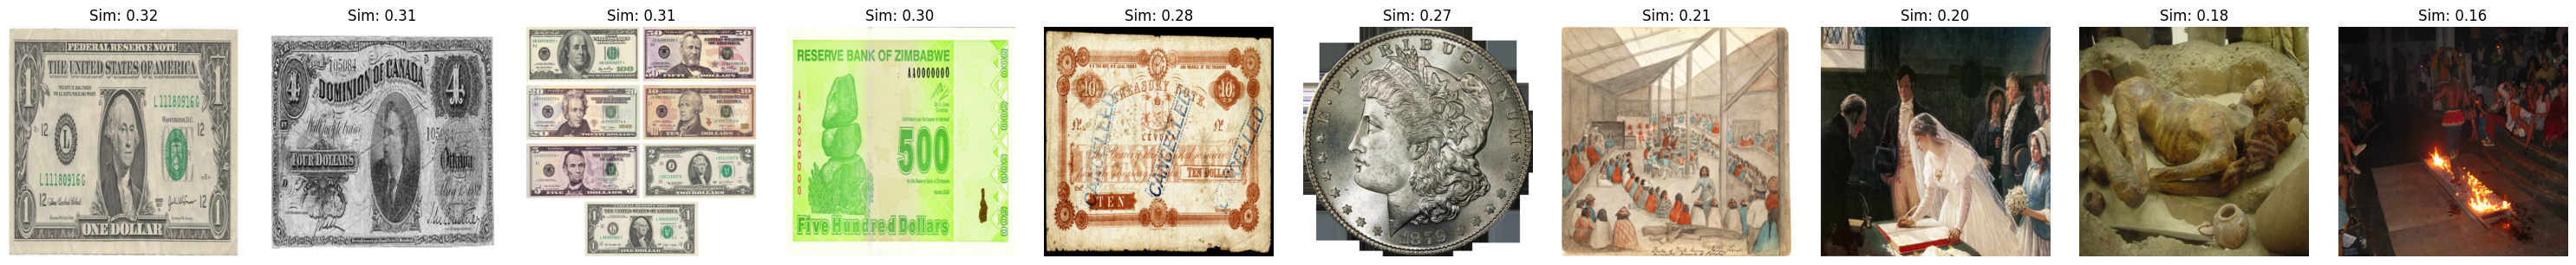

In [127]:
# Funzione per calcolare la similarità del coseno
def cosine_similarity(embedding1, embedding2):
    return torch.nn.functional.cosine_similarity(embedding1, embedding2, dim=-1)

# Prendi l'input della frase dall'utente
user_query = input("Inserisci una frase per cercare le immagini: ")

#prompt_sistema_clip = (
#    "Traduci ed espandi la seguente richiesta di ricerca in italiano. "
#    " Va consegnata ad al modello CLIP per fare l'embedding delle immagini "
#    "Non inventare nulla"
#)

#prompt_completo_clip = f"{prompt_sistema_clip}\n\nRichiesta: {user_query}"

# Chiede a Gemini di espandere la richiesta per CLIP
#sentence_input = chiedi_a_groq(prompt_completo_clip)
#print(f"Descrizione espansa per CLIP: {sentence_input}")

# Codifica la frase (ora la descrizione espansa da Gemini)
with torch.no_grad():
    text_embedding = text_model.encode(user_query, convert_to_tensor=True, show_progress_bar=False)
    text_embedding = text_embedding.unsqueeze(0).to(device)  # Aggiungi una dimensione per il batch e sposta al device
    text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True) # Normalizza l'embedding del testo

# Calcola la similarità del coseno con tutti gli embeddings delle immagini
similarities = cosine_similarity(text_embedding, embeddings_candidati.to(device))

# Ordina le immagini in base alla similarità
sorted_indices = torch.argsort(similarities, descending=True)
sorted_similarities = similarities[sorted_indices]
sorted_images = [immagini[i] for i in sorted_indices]

# Visualizza le immagini ordinate e i loro punteggi di similarità
print("Immagini ordinate per similarità con la frase:\n")
fig, axes = plt.subplots(1, len(sorted_images), figsize=(3 * len(sorted_images), 3))
if len(sorted_images) == 1:
    axes = [axes] # Ensure axes is iterable even for a single image

for i, (ax, img) in enumerate(zip(axes, sorted_images)):
    ax.imshow(img)
    ax.set_title(f"Sim: {sorted_similarities[i].item():.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [128]:
import torch
import requests
from io import BytesIO
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

print("Fase 1: Caricamento del processore e del modello nella GPU...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
print("Modello caricato con successo!")

Fase 1: Caricamento del processore e del modello nella GPU...


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Modello caricato con successo!


In [129]:
def calcola_score_vqa_unitor(image_pil, question):
    try:
        immagine = image_pil

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": "Image"},
                    {"type": "text", "text": question}
                ]
            }
        ]

        testo_formattato = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[testo_formattato], images=immagine, padding=True, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model(**inputs)
            next_token_logits = outputs.logits[0, -1, :]

        id_yes = processor.tokenizer.convert_tokens_to_ids("Yes")
        id_no = processor.tokenizer.convert_tokens_to_ids("No")

        logit_yes = next_token_logits[id_yes].float().item()
        logit_no = next_token_logits[id_no].float().item()

        logits_selezionati = torch.tensor([logit_yes, logit_no])
        probabilita = torch.softmax(logits_selezionati, dim=0)

        return probabilita[0].item()

    except Exception as e:
        print(f"Errore durante l'elaborazione: {e}")
        return None


Errore durante la chiamata a Gemini: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

[ERRORE] Impossibile caricare la risposta da Gemini (Errore API).
COPIA IL PROMPT QUI SOTTO E INCOLLALO NELLA CHAT DI GEMINI:
Sei un assistente specializzato in Visual Question Answering (VQA). Il tuo compito è trasformare una query testuale inserita dall'utente in 3 domande distinte con risposta sì/no.
Queste domande serviranno a verificare la presenza e i dettagli dell'oggetto o della scena descritta nella query all'interno di un'immagine.
Per garantire la massima utilità, rispetta rigorosamente queste linee guida:
1. Ogni domanda deve ammettere come unica risposta 'sì' o 'no'.
2. Le 3 domande devono approfondire temi e attributi visivi differenti (ad esempio: una sull'esistenza/presenza dell'oggetto principale, una sui suoi dettagli/attributi specifici c

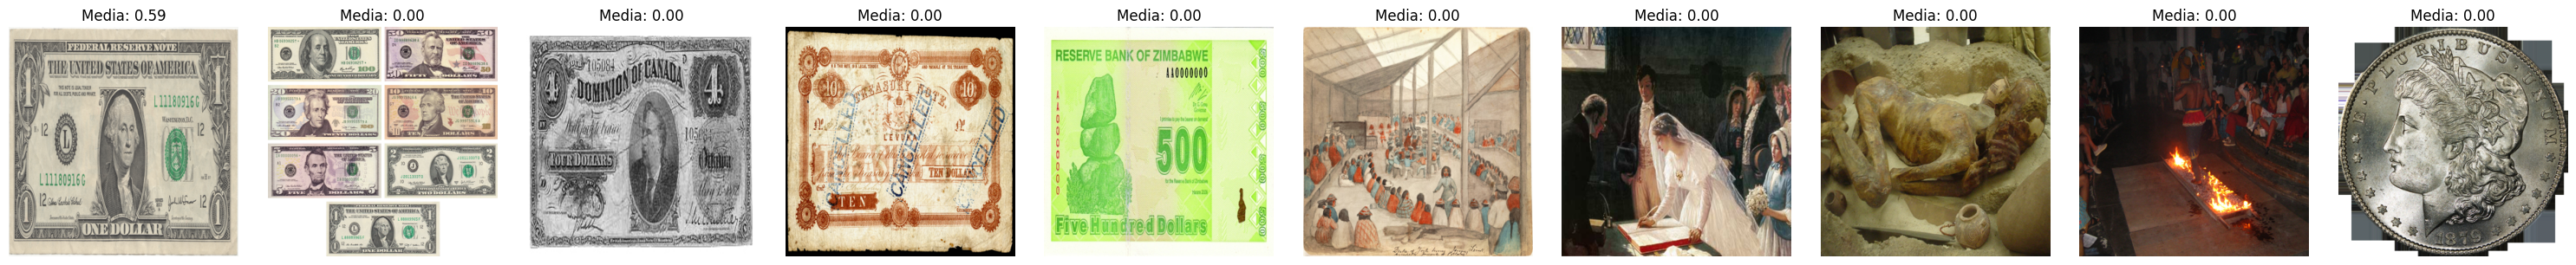

In [132]:
import json
import re

# PROMPT SISTEMA
prompt_sistema = (
    "Sei un assistente specializzato in Visual Question Answering (VQA). Il tuo compito è trasformare una query testuale inserita dall'utente in 3 domande distinte con risposta sì/no.\n"
    "Queste domande serviranno a verificare la presenza e i dettagli dell'oggetto o della scena descritta nella query all'interno di un'immagine.\n"
    "Per garantire la massima utilità, rispetta rigorosamente queste linee guida:\n"
    "1. Ogni domanda deve ammettere come unica risposta 'sì' o 'no'.\n"
    "2. Le 3 domande devono approfondire temi e attributi visivi differenti (ad esempio: una sull'esistenza/presenza dell'oggetto principale, una sui suoi dettagli/attributi specifici come colore o stato, e una sul contesto o sulla forma).\n"
    "REGOLA FONDAMENTALE: Restituisci ESCLUSIVAMENTE un array JSON valido. Ogni stringa DEVE essere racchiusa tra doppie virgolette.\n"
    "Esempio di output corretto: [\"Domanda 1?\", \"Domanda 2?\", \"Domanda 3?\"]"
)

# Uniamo i testi in un unico blocco
prompt_completo = f"{prompt_sistema}\n\nRichiesta dell'utente: {user_query}"

risposta_gemini = chiedi_a_gemini(prompt_completo)

# Inizializziamo la stringa che conterrà il testo da elaborare
testo_da_elaborare = ""

# --- CONTROLLO ERRORE DI CARICAMENTO API ---
if risposta_gemini is None or not risposta_gemini.strip():
    print("\n[ERRORE] Impossibile caricare la risposta da Gemini (Errore API).")
    print("=" * 60)
    print("COPIA IL PROMPT QUI SOTTO E INCOLLALO NELLA CHAT DI GEMINI:")
    print(prompt_completo)
    print("=" * 60)

    # Unico campo di input dove incollare tutta la risposta in blocco
    print("\nIncolla qui sotto la risposta intera copiata dalla chat di Gemini e premi Invio:")
    testo_da_elaborare = input()
else:
    print(f"Risposta ricevuta correttamente tramite API da Gemini:\n{risposta_gemini}")
    testo_da_elaborare = risposta_gemini

# --- PARSING DEL TESTO (SIA DA API CHE DA INCOLLA MANUALE) ---
domande_lista = []
testo_pulito = testo_da_elaborare.replace('```json', '').replace('```', '').strip()

try:
    # Tentativo 1: Parsing come JSON standard
    domande_lista = json.loads(testo_pulito)
    if not isinstance(domande_lista, list):
        raise ValueError("Il testo incollato non contiene una lista valida.")
except Exception as e:
    # Tentativo 2: Fallback se hai incollato del testo senza virgolette valide (es. formato [D1, D2, D3])
    print(f"\n[Info] Parsing JSON fallito ({e}), provo a estrarre le domande dal testo...")
    testo_senza_parentesi = testo_pulito.strip("[]")
    domande_lista = [d.strip(' "\'\n') for d in testo_senza_parentesi.split(',')]
    domande_lista = [d for d in domande_lista if d]

# Controllo finale di sicurezza sul numero di domande
if len(domande_lista) != 3:
    print(f"\n[Attenzione] Rilevate {len(domande_lista)} domande invece di 3. Procedo comunque con quelle trovate.")

print("\nDomande pronte per il VQA:")
for idx, d in enumerate(domande_lista):
    print(f" {idx + 1}. {d}")

# --- CALCOLO VQA E GRAFICI ---
vqa_results = []
print("\nFase 2: Calcolo dello score VQA medio (su 3 domande) per ciascuna immagine...")

for i, img in enumerate(immagini):
    punteggi_correnti = []

    for domanda in domande_lista:
        score = calcola_score_vqa_unitor(img, str(domanda))
        if score is not None:
            punteggi_correnti.append(score)

    # L'if e l'else ora sono perfettamente allineati!
    if punteggi_correnti:
        media_score = sum(punteggi_correnti) / len(punteggi_correnti)
        vqa_results.append((media_score, img))
        print(f"  Processed image {i+1}/{len(immagini)} - Media VQA Score: {media_score:.4f}")
    else:
        print(f"  Processed image {i+1}/{len(immagini)} - Nessun punteggio calcolato")

if vqa_results:
    vqa_results.sort(key=lambda x: x[0], reverse=True)
    sorted_scores = [res[0] for res in vqa_results]
    sorted_images = [res[1] for res in vqa_results]

    print("\nImmagini ordinate per MEDIA dello score VQA:\n")
    fig, axes = plt.subplots(1, len(sorted_images), figsize=(3 * len(sorted_images), 3))

    if len(sorted_images) == 1:
        axes = [axes]

    for i, (ax, img) in enumerate(zip(axes, sorted_images)):
        ax.imshow(img)
        ax.set_title(f"Media: {sorted_scores[i]:.2f}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Nessun punteggio VQA è stato calcolato.")

### Combinazione dei punteggi CLIP e VQA

Frase usata per la ricerca: banconota da un dollaro

Fase 3: Combinazione dei punteggi CLIP e VQA tramite MEDIA PESATA (40% CLIP, 60% VQA)...

Immagini ordinate per MEDIA PESATA dello score (40% CLIP, 60% VQA):



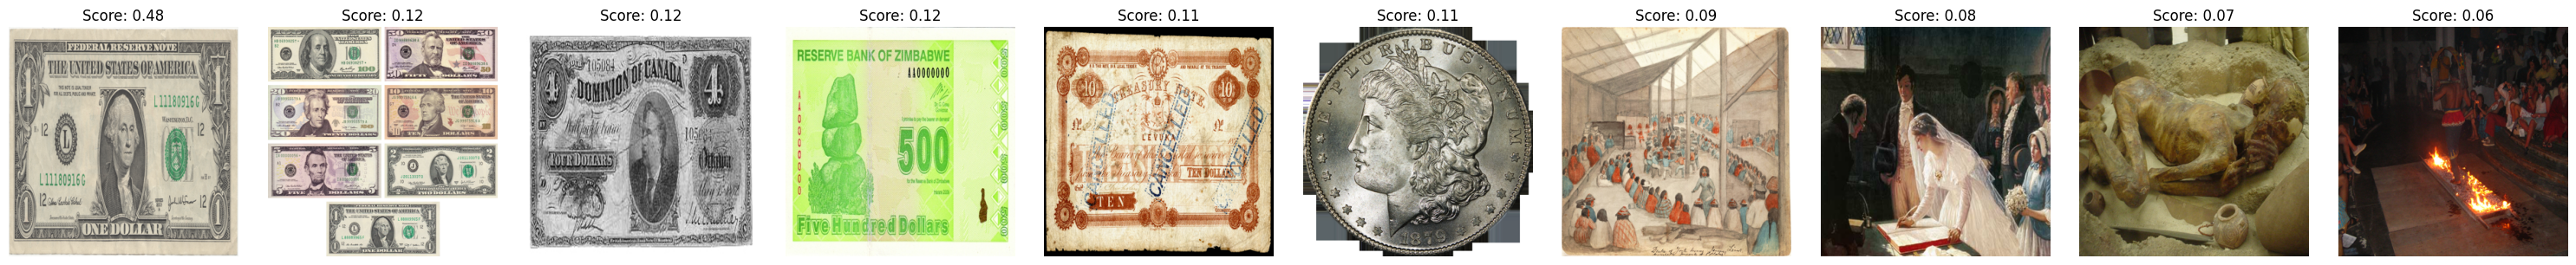

In [133]:
print(f"Frase usata per la ricerca: {user_query}")

print("\nFase 3: Combinazione dei punteggi CLIP e VQA tramite MEDIA PESATA (40% CLIP, 60% VQA)...")

# --- LA CORREZIONE È QUI ---
# Usiamo id(img) come chiave del dizionario, poiché restituisce un intero univoco per ogni immagine
vqa_mappa = {id(img): score for score, img in vqa_results}

combined_results = []

# Iteriamo sulla lista ORIGINALE delle immagini per usare correttamente l'indice di CLIP
for i, img in enumerate(immagini):

    # Recuperiamo il punteggio VQA medio usando sempre l'id dell'immagine
    vqa_score_medio = vqa_mappa.get(id(img))

    if vqa_score_medio is not None:
        # Prende il punteggio CLIP pre-calcolato a monte tramite l'indice i
        clip_score = similarities[i].item() if similarities.ndim == 1 else similarities[0][i].item()

        # Calcolo della media pesata (40% CLIP, 60% VQA) senza ricalcolare nulla!
        combined_score = 0.4 * clip_score + 0.6 * vqa_score_medio
        combined_results.append((combined_score, img))

if combined_results:
    # Ordina i risultati combinati finali in ordine decrescente
    combined_results.sort(key=lambda x: x[0], reverse=True)

    sorted_combined_scores = [res[0] for res in combined_results]
    sorted_images_combined = [res[1] for res in combined_results]

    print("\nImmagini ordinate per MEDIA PESATA dello score (40% CLIP, 60% VQA):\n")
    fig, axes = plt.subplots(1, len(sorted_images_combined), figsize=(3 * len(sorted_images_combined), 3))

    if len(sorted_images_combined) == 1:
        axes = [axes]

    for i, (ax, img) in enumerate(zip(axes, sorted_images_combined)):
        ax.imshow(img)
        ax.set_title(f"Score: {sorted_combined_scores[i]:.2f}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Nessun punteggio combinato è stato calcolato.")